# Notebook 05: Ensemble Models
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Combine ARIMA, Linear Regression and XGBoost into ensemble models to improve forecast accuracy

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR    = Path('../outputs/figures')
MODELS_DIR     = Path('../outputs/models')

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    return {'Model': name, 'MAE': round(mae,4),
            'RMSE': round(rmse,4), 'R2': round(r2,4),
            'MAPE': round(mape,2)}

Loaded: (144822, 39)


## 1. Rebuild Base Models

In [10]:
# Rebuild time series and features
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()
daily_temp.index = pd.to_datetime(daily_temp.index)
daily_temp = daily_temp.sort_index().asfreq('D').interpolate()

SPLIT_DATE = daily_temp.index[-60]
train = daily_temp[daily_temp.index < SPLIT_DATE]
test  = daily_temp[daily_temp.index >= SPLIT_DATE]

def make_features(series):
    df_feat = pd.DataFrame({'y': series})
    df_feat['lag_1']           = df_feat['y'].shift(1)
    df_feat['lag_7']           = df_feat['y'].shift(7)
    df_feat['lag_14']          = df_feat['y'].shift(14)
    df_feat['lag_30']          = df_feat['y'].shift(30)
    df_feat['rolling_mean_7']  = df_feat['y'].rolling(7).mean()
    df_feat['rolling_mean_30'] = df_feat['y'].rolling(30).mean()
    df_feat['rolling_std_7']   = df_feat['y'].rolling(7).std()
    df_feat['month']           = series.index.month
    df_feat['day_of_year']     = series.index.dayofyear
    df_feat['day_of_week']     = series.index.dayofweek
    return df_feat.dropna()

full_feat  = make_features(daily_temp)
split_idx  = full_feat.index.searchsorted(SPLIT_DATE)
X = full_feat.drop('y', axis=1)
y = full_feat['y']
X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_test  = y.iloc[split_idx:]

# ARIMA
print("Training ARIMA...")
arima_fit = ARIMA(train, order=(5,1,2)).fit()
arima_pred = arima_fit.forecast(steps=len(test)).values

# Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=5, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_pred = xgb_model.predict(X_test)

print("\nAll base models trained")
print(f"Test size: {len(y_test)} days")

Training ARIMA...
Training Linear Regression...
Training XGBoost...

All base models trained
Test size: 60 days


## 2. Ensemble Method 1 — Simple Average

In [11]:
# Simple average of all 3 models
simple_avg_pred = (arima_pred + lr_pred + xgb_pred) / 3
simple_avg_results = evaluate_model('Simple Average Ensemble',
                                     y_test.values, simple_avg_pred)


Model: Simple Average Ensemble
  MAE:  0.7711
  RMSE: 0.9093
  R²:   0.4330
  MAPE: 3.64%


## 3. Ensemble Method 2 — Weighted Average

In [12]:
# Weight by inverse MAE (better models get higher weight)
mae_arima = mean_absolute_error(y_test.values, arima_pred)
mae_lr    = mean_absolute_error(y_test.values, lr_pred)
mae_xgb   = mean_absolute_error(y_test.values, xgb_pred)

inv_mae = np.array([1/mae_arima, 1/mae_lr, 1/mae_xgb])
weights = inv_mae / inv_mae.sum()

print("Weights based on inverse MAE:")
print(f"  ARIMA:             {weights[0]:.4f} ({weights[0]*100:.1f}%)")
print(f"  Linear Regression: {weights[1]:.4f} ({weights[1]*100:.1f}%)")
print(f"  XGBoost:           {weights[2]:.4f} ({weights[2]*100:.1f}%)")

weighted_pred = (weights[0] * arima_pred +
                 weights[1] * lr_pred +
                 weights[2] * xgb_pred)

weighted_results = evaluate_model('Weighted Average Ensemble',
                                   y_test.values, weighted_pred)

Weights based on inverse MAE:
  ARIMA:             0.0638 (6.4%)
  Linear Regression: 0.4603 (46.0%)
  XGBoost:           0.4759 (47.6%)

Model: Weighted Average Ensemble
  MAE:  0.3165
  RMSE: 0.3901
  R²:   0.8957
  MAPE: 1.52%


## 4. Ensemble Method 3 — Stacking (Meta-Learner)

In [13]:
# Stack base model predictions as features for a meta-learner
# Use first 70% of test-equivalent data for meta-train, rest for meta-test
meta_split = int(len(y_test) * 0.5)

# Stack predictions into feature matrix
stacked_features = np.column_stack([arima_pred, lr_pred, xgb_pred])

X_meta_train = stacked_features[:meta_split]
y_meta_train = y_test.values[:meta_split]
X_meta_test  = stacked_features[meta_split:]
y_meta_test  = y_test.values[meta_split:]

# Ridge regression as meta-learner
meta_learner = Ridge(alpha=1.0)
meta_learner.fit(X_meta_train, y_meta_train)
stacking_pred = meta_learner.predict(X_meta_test)

print("Meta-learner coefficients:")
print(f"  ARIMA weight:             {meta_learner.coef_[0]:.4f}")
print(f"  Linear Regression weight: {meta_learner.coef_[1]:.4f}")
print(f"  XGBoost weight:           {meta_learner.coef_[2]:.4f}")

stacking_results = evaluate_model('Stacking Ensemble (Ridge meta)',
                                   y_meta_test, stacking_pred)

Meta-learner coefficients:
  ARIMA weight:             -0.0045
  Linear Regression weight: 0.3455
  XGBoost weight:           0.5733

Model: Stacking Ensemble (Ridge meta)
  MAE:  0.3559
  RMSE: 0.4419
  R²:   0.6758
  MAPE: 1.64%


## 5. Full Comparison — Base Models vs Ensembles

In [14]:
# Individual model results on same test set
arima_results  = evaluate_model('ARIMA',             y_test.values, arima_pred)
lr_results     = evaluate_model('Linear Regression', y_test.values, lr_pred)
xgb_results    = evaluate_model('XGBoost',           y_test.values, xgb_pred)

# Full comparison table
all_results = pd.DataFrame([
    arima_results, lr_results, xgb_results,
    simple_avg_results, weighted_results
])
all_results = all_results.set_index('Model')

print("FULL MODEL COMPARISON — BASE MODELS vs ENSEMBLES")
print(all_results.to_string())


Model: ARIMA
  MAE:  2.1427
  RMSE: 2.4541
  R²:   -3.1300
  MAPE: 10.12%

Model: Linear Regression
  MAE:  0.2967
  RMSE: 0.3579
  R²:   0.9122
  MAPE: 1.45%

Model: XGBoost
  MAE:  0.2870
  RMSE: 0.3639
  R²:   0.9092
  MAPE: 1.39%
FULL MODEL COMPARISON — BASE MODELS vs ENSEMBLES
                              MAE    RMSE      R2   MAPE
Model                                                   
ARIMA                      2.1427  2.4541 -3.1300  10.12
Linear Regression          0.2967  0.3579  0.9122   1.45
XGBoost                    0.2870  0.3639  0.9092   1.39
Simple Average Ensemble    0.7711  0.9093  0.4330   3.64
Weighted Average Ensemble  0.3165  0.3901  0.8957   1.52


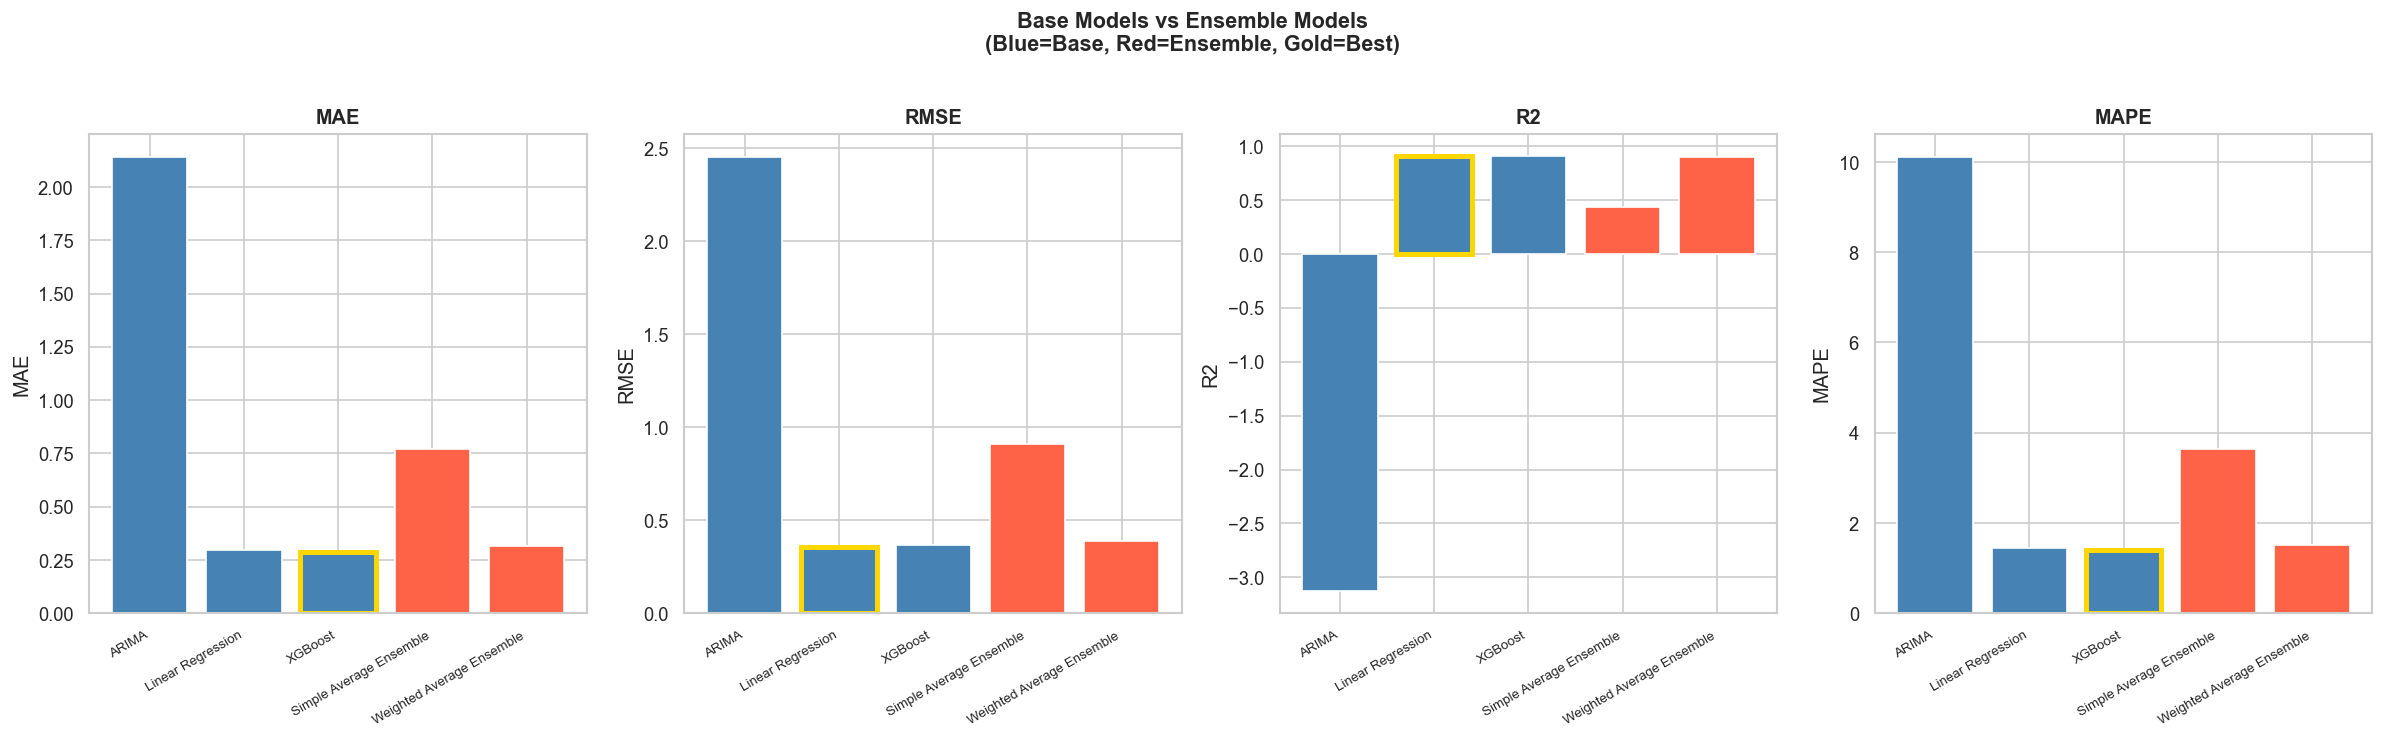

Saved: 26_ensemble_comparison.png


In [15]:
# Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
metrics = ['MAE', 'RMSE', 'R2', 'MAPE']
bar_colors = ['steelblue', 'steelblue', 'steelblue',
              'tomato', 'tomato']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(range(len(all_results)),
                       all_results[metric],
                       color=bar_colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(all_results)))
    axes[i].set_xticklabels(all_results.index, rotation=30,
                             ha='right', fontsize=8)
    # Gold on best
    best_pos = (all_results[metric].values.argmin()
                if metric in ['MAE','RMSE','MAPE']
                else all_results[metric].values.argmax())
    bars[best_pos].set_edgecolor('gold')
    bars[best_pos].set_linewidth(3)

plt.suptitle('Base Models vs Ensemble Models\n(Blue=Base, Red=Ensemble, Gold=Best)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '26_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 26_ensemble_comparison.png")

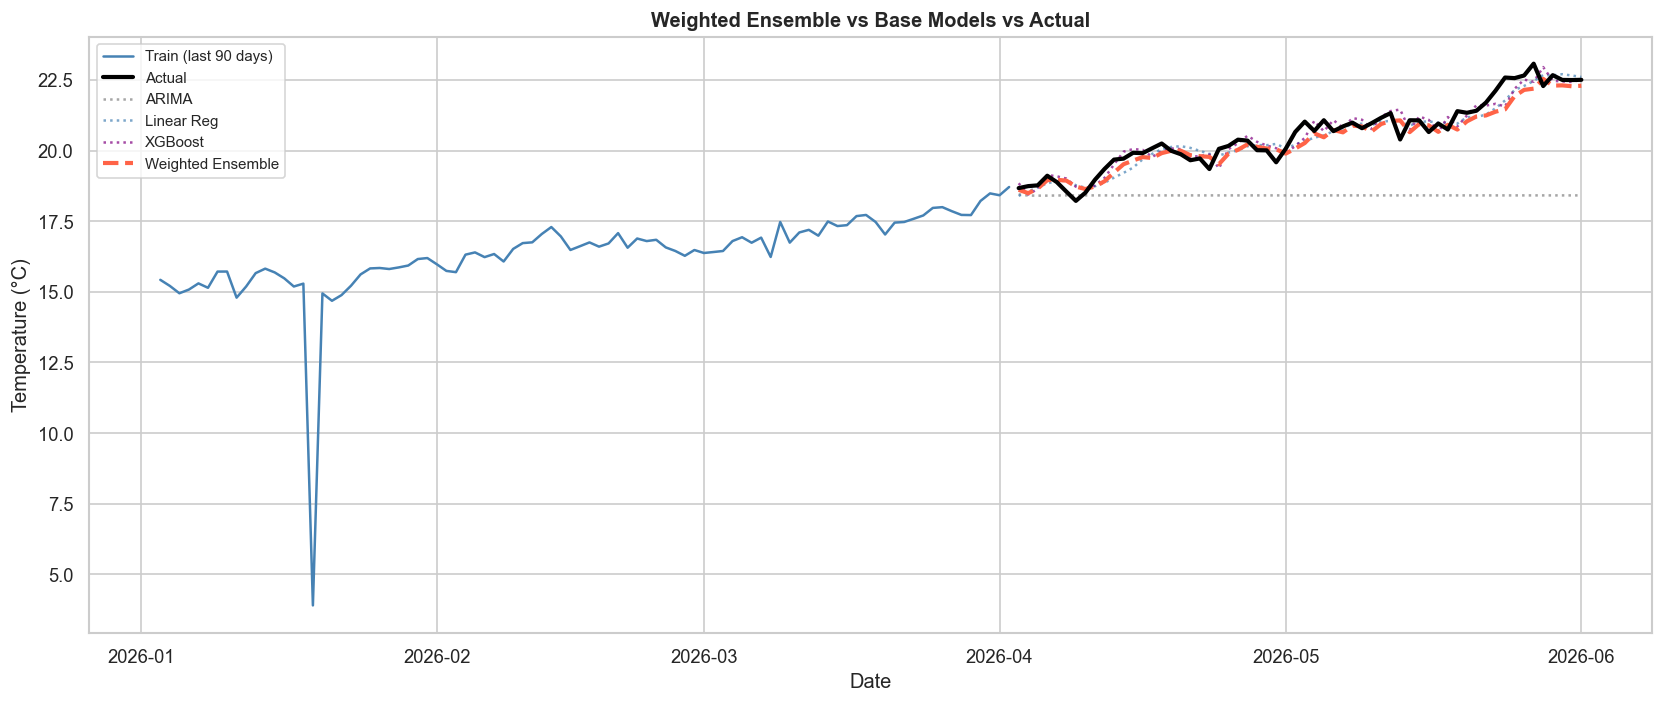

Saved: 27_ensemble_forecast.png


In [16]:
# Best ensemble forecast plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-90:], train.values[-90:],
        color='steelblue', linewidth=1.5, label='Train (last 90 days)')
ax.plot(test.index, test.values,
        color='black', linewidth=2.5, label='Actual', zorder=5)
ax.plot(test.index, arima_pred,
        color='gray', linewidth=1.5, linestyle=':', label='ARIMA', alpha=0.7)
ax.plot(test.index, lr_pred,
        color='steelblue', linewidth=1.5, linestyle=':', label='Linear Reg', alpha=0.7)
ax.plot(test.index, xgb_pred,
        color='purple', linewidth=1.5, linestyle=':', label='XGBoost', alpha=0.7)
ax.plot(test.index, weighted_pred,
        color='tomato', linewidth=2.5, linestyle='--', label='Weighted Ensemble')
ax.set_title('Weighted Ensemble vs Base Models vs Actual',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '27_ensemble_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 27_ensemble_forecast.png")